# Forecast-Window Delta Analysis (Paper Figure 3)

This notebook reproduces the **paper's Figure 3 logic** using reusable package modules instead of inline function definitions.

## What This Notebook Does
1. Loads a standardized 4-degree model catalog and the paper-year policy.
2. Scans available yearly files to identify usable models and recommend one debug target.
3. Runs one model to produce a detailed window-delta table and a single-model heatmap.
4. Runs all models, exports matrix-style CSV outputs, and plots the 3-panel delta summary.

## Important Evaluation Rules
- Forecast windows: `1-5`, `6-10`, `11-15`, `16-20`, `21-25`, `26-30` days.
- Tolerances: `+/-2`, `+/-2`, `+/-3`, `+/-3`, `+/-5`, `+/-5` days.
- Delta definition: `Model - Climatology` (negative means improvement).
- CMZ mask: legacy polygon option enabled by default to match prior scripts.


In [1]:
from pathlib import Path

from IPython.display import display

from monsoonbench.metrics.cmz_window_metrics import WindowScoringConfig
from monsoonbench.utils.forecast_window_pipeline import (
    PAPER_YEARS_BY_MODEL_4DEG,
    build_model_run_config,
    choose_recommended_model,
    compute_window_delta_table,
    get_default_four_degree_model_specs,
    run_multi_model_window_analysis,
    save_window_analysis_outputs,
    scan_forecast_data_coverage,
)
from monsoonbench.visualization.cmz_window_plots import (
    plot_multi_model_window_deltas,
    plot_window_delta_heatmap,
)

## Step 1: Configure Shared Inputs

This block defines project paths and common runtime options.

- `base_config` controls climatology/model computation settings.
- `scoring_config` controls window classification behavior.
- `model_specs` is a reusable 4-degree catalog aligned with repository structure.


In [2]:
repo_root = next(
    (p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").exists()),
    Path.cwd(),
)
data_dir = repo_root / "data"
output_dir = repo_root / "examples" / "demo_notebooks" / "outputs"
output_dir.mkdir(parents=True, exist_ok=True)

base_config = {
    "imd_folder": data_dir / "imd_rainfall_data" / "4p0",
    "thres_file": data_dir / "imd_onset_threshold" / "mwset4x4.nc4",
    "mok": True,
    "max_forecast_day": 30,
    "file_pattern": "{}.nc",
    "temporal_agg_mode": "year_then_average",
    "use_legacy_cmz_polygon": True,
    "strict_year_failures": False,
}
scoring_config = WindowScoringConfig(
    obs_window_mode="bin",
    classification_mode="strict_window",
    fn_tn_obs_mode="bin",
    mr_denom_mode="obs_in_bin",
    aggregate_mode="gridmean",
)
model_specs = get_default_four_degree_model_specs(data_dir)
print("Output directory:", output_dir)

Output directory: c:\Users\50573\Documents\AAASlashie\MSCAPP\2026-WINTER\DATA 27100\monsoon-bench\examples\demo_notebooks\outputs


## Step 2: Data Coverage Check

Before running expensive computations, verify each model has the years required by the paper policy.
The recommended model is chosen by: paper-year support -> ensemble check -> number of available years.


In [3]:
coverage_df = scan_forecast_data_coverage(model_specs, PAPER_YEARS_BY_MODEL_4DEG)
display_cols = [
    "model",
    "model_type",
    "supports_paper_years",
    "ensemble_check_ok",
    "n_years",
    "min_year",
    "max_year",
    "missing_paper_years",
]
display(coverage_df[display_cols])

recommended = choose_recommended_model(coverage_df)
recommended_name = str(recommended["model"])
print("Recommended debug model:", recommended_name)

,model,model_type,supports_paper_years,ensemble_check_ok,n_years,min_year,max_year,missing_paper_years
2,fuxi,deterministic,True,True,61,1964,2024,[]
3,graphcast,deterministic,True,True,60,1965,2024,[]
6,ngcm,probabilistic,True,True,60,1965,2024,[]
5,fuxi-s2s,probabilistic,True,True,20,2002,2021,[]
0,ifs,probabilistic,True,True,20,2004,2023,[]
1,aifs,deterministic,True,True,6,2019,2024,[]
4,gencast,probabilistic,True,True,6,2019,2024,[]


Recommended debug model: fuxi


## Step 3: Single-Model Walkthrough

Run one model end-to-end first. This is the best place to inspect:
- per-window MAE/FAR/MR deltas
- TP/FP/FN/TN counts
- processed vs skipped years

Change `target_model` if you want to debug a specific model directly.


Computing climatological onset from 124 years: 1901-2024
Loading IMD rainfall from: c:\Users\50573\Documents\AAASlashie\MSCAPP\2026-WINTER\DATA 27100\monsoon-bench\data\imd_rainfall_data\4p0\1901.nc
Renamed dimensions: {'TIME': 'time'}
Using MOK date (June 2nd) (1901-06-02) as start date for onset detection
Loading IMD rainfall from: c:\Users\50573\Documents\AAASlashie\MSCAPP\2026-WINTER\DATA 27100\monsoon-bench\data\imd_rainfall_data\4p0\1902.nc
Renamed dimensions: {'TIME': 'time'}
Using MOK date (June 2nd) (1902-06-02) as start date for onset detection
Loading IMD rainfall from: c:\Users\50573\Documents\AAASlashie\MSCAPP\2026-WINTER\DATA 27100\monsoon-bench\data\imd_rainfall_data\4p0\1903.nc
Renamed dimensions: {'TIME': 'time'}
Using MOK date (June 2nd) (1903-06-02) as start date for onset detection
Loading IMD rainfall from: c:\Users\50573\Documents\AAASlashie\MSCAPP\2026-WINTER\DATA 27100\monsoon-bench\data\imd_rainfall_data\4p0\1904.nc
Renamed dimensions: {'TIME': 'time'}
Using MO

,metric,window,model,climatology,delta,model_tp,model_fp,model_fn,model_tn
0,MAE (days),1-5,1.268254,4.579365,-3.311111,40,8,43,728
1,FAR (%),1-5,1.049231,3.906401,-2.857170,40,8,43,728
2,MR (%),1-5,51.666667,72.500000,-20.833333,40,8,43,728
3,MAE (days),6-10,2.189550,4.672884,-2.483333,36,20,53,710
4,FAR (%),6-10,2.775068,4.180056,-1.404988,36,20,53,710
5,MR (%),6-10,61.666667,80.000000,-18.333333,36,20,53,710
6,MAE (days),11-15,4.229167,5.682937,-1.453770,33,29,63,694
7,FAR (%),11-15,4.045036,7.004187,-2.959151,33,29,63,694
8,MR (%),11-15,69.166667,76.666667,-7.500000,33,29,63,694
9,MAE (days),16-20,5.034012,5.878704,-0.844691,34,53,54,678


Saved: c:\Users\50573\Documents\AAASlashie\MSCAPP\2026-WINTER\DATA 27100\monsoon-bench\examples\demo_notebooks\outputs\forecast_window_skill_single_fuxi.png


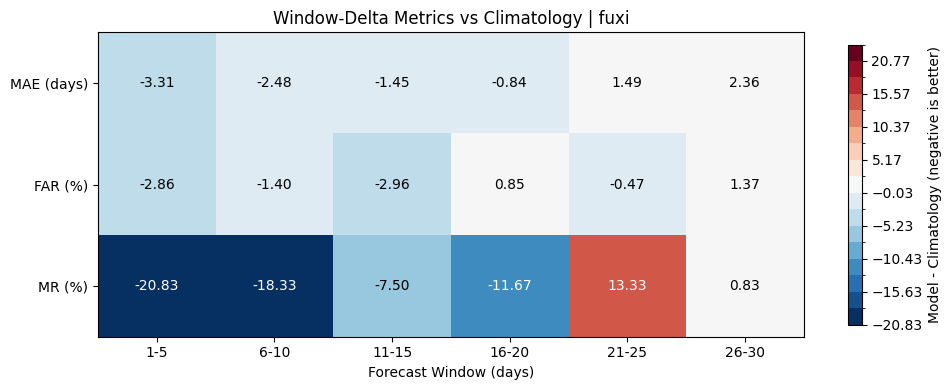

In [4]:
target_model = recommended_name
single_run = build_model_run_config(
    model_name=target_model,
    base_config=base_config,
    model_specs=model_specs,
    paper_years_by_model=PAPER_YEARS_BY_MODEL_4DEG,
    scoring=scoring_config,
)
single_delta = compute_window_delta_table(single_run)
display(
    single_delta[
        [
            "metric",
            "window",
            "model",
            "climatology",
            "delta",
            "model_tp",
            "model_fp",
            "model_fn",
            "model_tn",
        ]
    ]
)

single_plot_path = output_dir / f"forecast_window_skill_single_{target_model}.png"
_ = plot_window_delta_heatmap(
    single_delta, model_name=target_model, save_path=single_plot_path
)
print("Saved:", single_plot_path)

## Step 4: Batch Run for Paper Figure 3

This cell executes the full multi-model workflow and exports reusable artifacts:
- per-model long delta tables
- matrix-form CSV files for MAE/FAR/MR (+ model order list)
- combined long table for all models
- three-panel heatmap used for final comparison



Running model=ifs, years=[2019, 2020, 2021, 2022, 2023]
Computing climatological onset from 124 years: 1901-2024
Loading IMD rainfall from: c:\Users\50573\Documents\AAASlashie\MSCAPP\2026-WINTER\DATA 27100\monsoon-bench\data\imd_rainfall_data\4p0\1901.nc
Renamed dimensions: {'TIME': 'time'}
Using MOK date (June 2nd) (1901-06-02) as start date for onset detection
Loading IMD rainfall from: c:\Users\50573\Documents\AAASlashie\MSCAPP\2026-WINTER\DATA 27100\monsoon-bench\data\imd_rainfall_data\4p0\1902.nc
Renamed dimensions: {'TIME': 'time'}
Using MOK date (June 2nd) (1902-06-02) as start date for onset detection
Loading IMD rainfall from: c:\Users\50573\Documents\AAASlashie\MSCAPP\2026-WINTER\DATA 27100\monsoon-bench\data\imd_rainfall_data\4p0\1903.nc
Renamed dimensions: {'TIME': 'time'}
Using MOK date (June 2nd) (1903-06-02) as start date for onset detection
Loading IMD rainfall from: c:\Users\50573\Documents\AAASlashie\MSCAPP\2026-WINTER\DATA 27100\monsoon-bench\data\imd_rainfall_data\

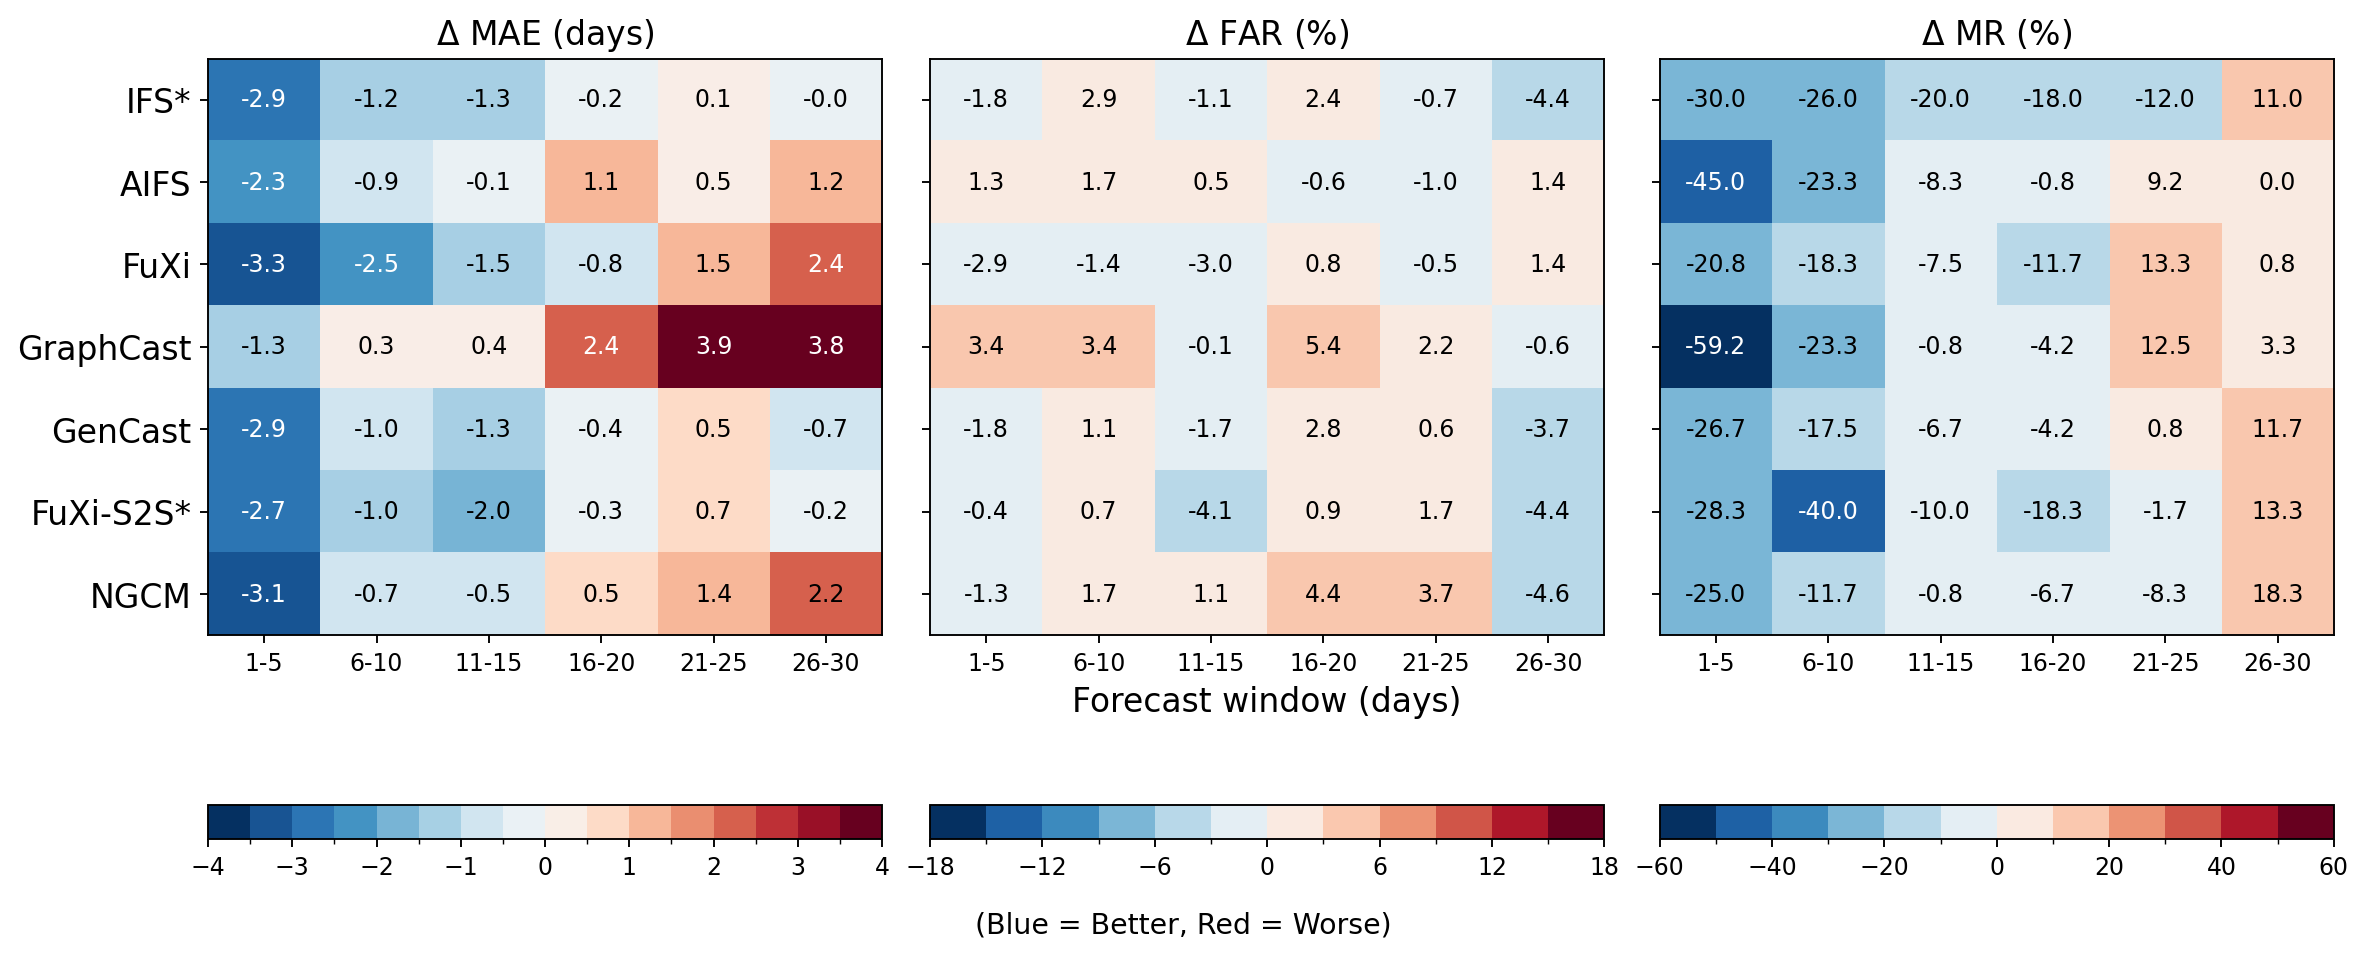

In [5]:
batch_result = run_multi_model_window_analysis(
    base_config=base_config,
    model_specs=model_specs,
    paper_years_by_model=PAPER_YEARS_BY_MODEL_4DEG,
    scoring=scoring_config,
)
saved_files = save_window_analysis_outputs(
    batch_result, output_dir=output_dir, prefix="forecast_window_skill"
)

multi_plot_path = output_dir / "forecast_window_skill_delta_panels.png"
_ = plot_multi_model_window_deltas(
    batch_result["delta_for_plot"],
    batch_result["plot_model_order"],
    batch_result["window_labels"],
    batch_result["plot_model_labels"],
    save_path=multi_plot_path,
)
print("Saved plot:", multi_plot_path)
print("Saved CSV files:")
for key, path in saved_files.items():
    print(f"- {key}: {path}")